<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/Copy_of_best_version_MLNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5PAM2034-0105-2025 - Assignment 3 - Data Analysis and Exploration

NAME:
STUDENT ID:

In this assignment, you are tasked with exploring a dataset using machine learning algorithms. You will train and evaluate a Random Forest Regressor to predict prices of regional flights in India.

You will need to write a short (1-2 page) report to accompany your code, explaining your results and analysis of the dataset.

In [1]:
#Module Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import ensemble

#Add any additional imports here


# Data Processing

The dataset used in this assignment can be found on [Kaggle](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction). You will be using the data for the Economy class flights only, and will need to clean up the dataset.

Begin by loading in the economy.csv file, which is linked in the Canvas assignment, using pandas. You will need to derive new features from the data to create something you can train models with. The features in your training dataset should be:

FEATURES
1) Airline: The name of the airline company. Categorical.
2) Source City: City from which the flight takes off. Categorical.
3) Departure Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
4) Stops: The number of stops on the flight path. Categorical.
5) Arrival Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
6) Destination City: City where the flight will land. Categorical.
7) Duration: The number of hours the flight takes as a continuous real number. Continuous.
8) Lead Time: The number of days between the flight date and the booking date. Discrete.
11) Price: The cost of the flight. Continuous.

Drop any unused features from the dataset, such as the flight code, separate out the target variable and split into a training and testing set.

In [5]:
data = pd.read_csv('/content/economy(2).csv')
df = pd.DataFrame(data)
df = df.dropna()

print(df['price'].max())

df['price'] = df['price'].str.replace(',', '').astype(float).dropna()

df['price'] = np.log(df['price'])

q3 = np.quantile(df['price'], 0.75)
print(q3)
iqr = q3 - np.quantile(df['price'], 0.25)
print(iqr)
outlier_threshold = q3 + 1.5*iqr
print("THRESHOLD:  ", outlier_threshold)

#df = df[df['price'] < outlier_threshold]

df['price']



9,999
8.954931860074698
0.6185413794831458
THRESHOLD:   9.882743929299416


,price
0,8.691651
1,8.691651
2,8.692154
3,8.691986
4,8.691986
...,...
206769,8.948586
206770,8.950144
206771,9.064158
206772,9.064158


Initial transformations

In [6]:
#turn airline, to and from columns categorical
df['airline'] = df['airline'].astype('category')

#rename to and from to src and destination
df['Source_City'] = df['from'].astype('category')
df['Destination_City'] = df['to'].astype('category')

#further columns require string manipulation and other operations
#reformat then cut both time columns
df['dep_time'] = df['dep_time'].str.replace(':', '').astype(int)
df['arr_time'] = df['arr_time'].str.replace(':', '').astype(int)

bins = [0000, 1200, 2000, 2359]
labels = ['Morning', 'Daytime', 'Night']

df['dep_time'] = pd.cut(df['dep_time'], bins=bins, labels = labels)
df['arr_time'] = pd.cut(df['arr_time'], bins=bins, labels = labels)

#time taken conversion to duration
#first remove extra characters, using a list

replacements = [('h', ''), ('m', ''), (' ', '')]

for old_, new_ in replacements:
    df['time_taken'] = df['time_taken'].str.replace(old_, new_)

#index the minutes and convert them to a decimal to add back on
for vals in df['time_taken'][-2:].astype(float):
  df['minutes_decimal'] = vals / 60 * 100
#take the first 2 digits for hours
df['hours'] = df['time_taken'].str[:2]
df['duration'] = (df['hours'] + df['minutes_decimal'].astype(str))
#take away the decimal point
df['duration'] = df['duration'].str.replace('.', '')

#back to  a float
df['duration'] = df['duration'].str[:4]
df['duration'] = df['duration'].astype(float) / 100
df['duration'].head()

,duration
0,2.4
1,2.4
2,2.4
3,2.4
4,2.4


Stops column

In [7]:
for stopval in df['stop']:
  stopval = np.where(stopval == 'non-stop', 1, 0)

df['stop'] = stopval
df['stop'].head()


,stop
0,0
1,0
2,0
3,0
4,0


Lead times: since Feb 11, 2022

In [8]:
from datetime import datetime

dates_list = []
#assign current format as a string
format = '%d-%m-%Y'

#make our dates adhere to the accepted format
#by iterating over rows with strptime
for datestrings in df['date']:
  dates_list.append(datetime.strptime(datestrings, format))

date0 = datetime(2022, 2, 11, 0, 0)

days_between  = []

for dates in dates_list:
  days_between.append(np.abs(date0 - dates).days)

#turn into a column
df['lead_time'] = pd.Series(days_between).astype(int)
df['lead_time']

,lead_time
0,0
1,0
2,0
3,0
4,0
...,...
206769,48
206770,48
206771,48
206772,48


Make price continuous, observe distribution, REMOVE OUTLIERS q3 + 1.5iqr

<Axes: title={'center': 'Distribution of Prices'}, xlabel='Prices'>

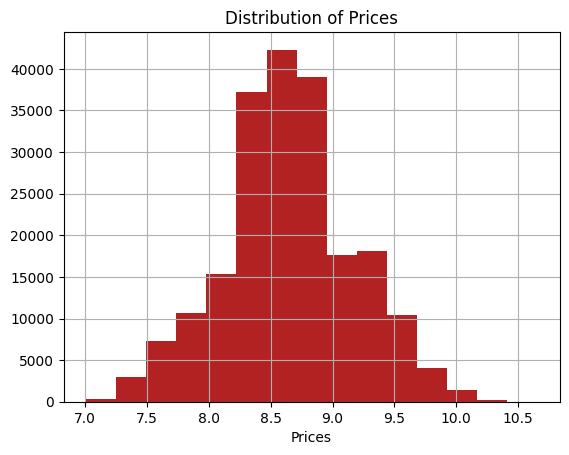

In [9]:
plt.title("Distribution of Prices")

plt.xlabel("Prices")
df['price'].hist(bins = 15, color='firebrick')

In [10]:
#list all categorical columns
catcols = df.select_dtypes(include=['category']).columns.tolist()
print(catcols)

#create the encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
onehot_done = encoder.fit_transform(df[catcols])

#make note of column names
cols = encoder.get_feature_names_out(catcols)

#create a df with these columns
onehot_df = pd.DataFrame(onehot_done, columns = cols)
#add it back to df
df = pd.concat([df, onehot_df], axis=1)
df.head()

['airline', 'dep_time', 'arr_time', 'Source_City', 'Destination_City']


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,...,Source_City_Delhi,Source_City_Hyderabad,Source_City_Kolkata,Source_City_Mumbai,Destination_City_Bangalore,Destination_City_Chennai,Destination_City_Delhi,Destination_City_Hyderabad,Destination_City_Kolkata,Destination_City_Mumbai
0,11-02-2022,SpiceJet,SG,8709,Daytime,Delhi,0210,0,Night,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,11-02-2022,SpiceJet,SG,8157,Morning,Delhi,0220,0,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,11-02-2022,AirAsia,I5,764,Morning,Delhi,0210,0,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,11-02-2022,Vistara,UK,995,Morning,Delhi,0215,0,Daytime,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,11-02-2022,Vistara,UK,963,Morning,Delhi,0220,0,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Drop unnecessary columns

In [11]:
df = df.drop(columns = ['Source_City', 'Destination_City', 'date', 'ch_code', 'num_code', 'from', 'time_taken', 'to', 'minutes_decimal', 'hours'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   airline                     206774 non-null  category
 1   dep_time                    206774 non-null  category
 2   stop                        206774 non-null  int64   
 3   arr_time                    206774 non-null  category
 4   price                       206774 non-null  float64 
 5   duration                    206774 non-null  float64 
 6   lead_time                   206774 non-null  int64   
 7   airline_Air India           206774 non-null  float64 
 8   airline_AirAsia             206774 non-null  float64 
 9   airline_GO FIRST            206774 non-null  float64 
 10  airline_Indigo              206774 non-null  float64 
 11  airline_SpiceJet            206774 non-null  float64 
 12  airline_StarAir             206774 non-null  float64 
 13 

# Model Training

Implement and train a random forest regressor, using sklearn. Explore a range of hyperparamter settings for the model to find the best fitting result.

In [13]:
from sklearn.model_selection import train_test_split

df = df.dropna()

#define features then split
#filtered above
y = df['price']

feature_columns = ['stop', 'duration', 'lead_time'] + list(cols)
X = df[feature_columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(oob_score= True,
                               n_estimators = 100,
                               n_jobs = -1,
                               min_samples_split = 8,
                               max_depth = 20,
                               bootstrap=True,
                               max_features=8)

rf_reg.fit(X_train, y_train)
y_preds = rf_reg.predict(X_test)

print(y_preds)
print(y_test)

[8.35335749 8.89176768 9.22242672 ... 8.52655693 8.67067797 8.83885246]
90758      8.311644
201430     8.865170
63634      9.198167
117195     8.653645
3138      10.036706
            ...    
78675      8.992557
56110      8.771835
47629      8.247744
133090     8.621193
122708     8.773539
Name: price, Length: 41355, dtype: float64


# Analysis

Evaluate the results of your model, consider how the pricing of flights relates to other features in the dataset, such as the carrier or departure time, and use your trained model to support any conclusions. Create any relevant plots to include in your report.

SD:   0.2640598919313206


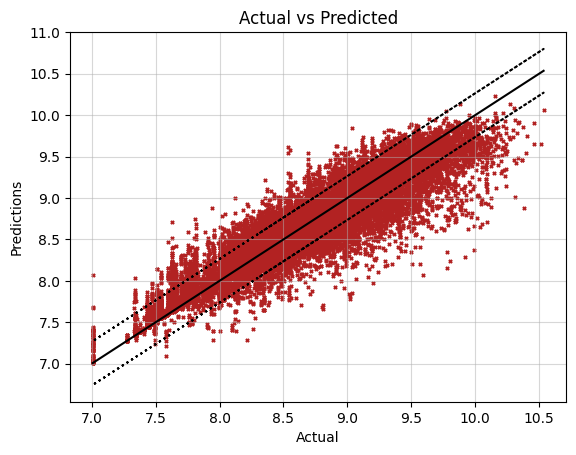

In [14]:
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label= 'Correct')

#trying sd not 3000, 1/2 an sd
sd = np.std(y_test)/2    #relabel
print('SD:  ' ,sd)
#from prev draft
#correct and incorrect preds
#points under and over line within
upper = y_test + sd
lower = y_test -sd
plt.plot(y_test, upper, color = 'black', label = 'Correct Upper', linestyle='dotted')
plt.plot(y_test, lower, color = 'black', label = 'Correct Lower', linestyle= 'dotted')
plt.scatter(y_test, y_preds, marker = 'x', s=5, color='firebrick')
plt.grid(alpha=0.5)
plt.show()

Proportion %

In [15]:
#create a df (c for class)
len(y_test)
cdf = pd.DataFrame([range(0, len(y_test)), y_test, y_preds]).T   #clean up
cdf.head()

upper = y_preds + sd
lower = y_preds - sd

overs = []
unders = []

#1 is x y is 2
overs.append((cdf[1] > (cdf[2]+ sd/2)).mean())
print(overs)
unders.append((cdf[1] < (cdf[2]- sd/2)).mean())
print(unders)

#find inbetweens by all ovr then take away percentages already calculated
slight_overs = []
slight_unders = []

slight_overs.append((cdf[1] > (cdf[2])).mean())
print(slight_overs)
slight_unders.append((cdf[1] < (cdf[2])).mean())
print(slight_unders)

third_from_bottom_up = (0.4017 - 0.1523) * 100
second_bottom = (0.5982 - 0.1659) * 100

print(f"There is {15.23}% that the model significantly overpredicts, {third_from_bottom_up} that are in the upper middle band, slightly overestimated")
print(f"There is {16.59}% that signifcantly UNDER predicts prices and {second_bottom} that slightly underpredict")
#be clear with hiw differs from version with tp and tf etc
miss_over_correct =(15.28 + 16.59) /  (24.94 + 43.23)
#relevant subtractions
print(miss_over_correct)

[np.float64(0.15330673437311088)]
[np.float64(0.16575988393180993)]
[np.float64(0.397170837867247)]
[np.float64(0.602829162132753)]
There is 15.23% that the model significantly overpredicts, 24.94 that are in the upper middle band, slightly overestimated
There is 16.59% that signifcantly UNDER predicts prices and 43.23 that slightly underpredict
0.467507701334898


Correct (within lines) vs incorrect (outside)

In [339]:
#precision all classification style metrics


Residuals histogram

<Axes: title={'center': 'Residual Distribtution'}>

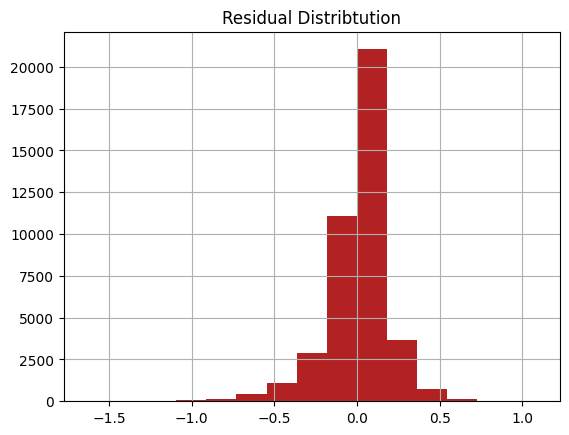

In [16]:
plt.title("Residual Distribtution")
(y_preds - y_test).hist(bins=15, color='firebrick')

In [17]:
rf_reg.oob_score_

0.8722756573253903

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_preds)
r2 = r2_score(y_test, y_preds)     #2
oob = rf_reg.oob_score_

print(mse)
print(r2)
print(oob)
#print(rf_reg.score_)

0.035349784809884786
0.8732576075986614
0.8722756573253903


Feature importances

In [343]:
list(zip(rf_reg.feature_names_in_, rf_reg.feature_importances_))

[('stop', np.float64(0.0)),
 ('duration', np.float64(0.1888909880265919)),
 ('lead_time', np.float64(0.4757043107304723)),
 ('airline_Air India', np.float64(0.018651268447528385)),
 ('airline_AirAsia', np.float64(0.06248520954424885)),
 ('airline_GO FIRST', np.float64(0.011291978854666804)),
 ('airline_Indigo', np.float64(0.0340826739098088)),
 ('airline_SpiceJet', np.float64(0.004319785681442911)),
 ('airline_StarAir', np.float64(7.19150787562972e-05)),
 ('airline_Trujet', np.float64(0.00021086739935618774)),
 ('airline_Vistara', np.float64(0.04066443842472594)),
 ('dep_time_Daytime', np.float64(0.005197862675186871)),
 ('dep_time_Morning', np.float64(0.006473525887800704)),
 ('dep_time_Night', np.float64(0.004017190663341058)),
 ('arr_time_Daytime', np.float64(0.0053033219640065375)),
 ('arr_time_Morning', np.float64(0.006554087214467269)),
 ('arr_time_Night', np.float64(0.004316416639349151)),
 ('Source_City_Bangalore', np.float64(0.010518949955369918)),
 ('Source_City_Chennai', np.

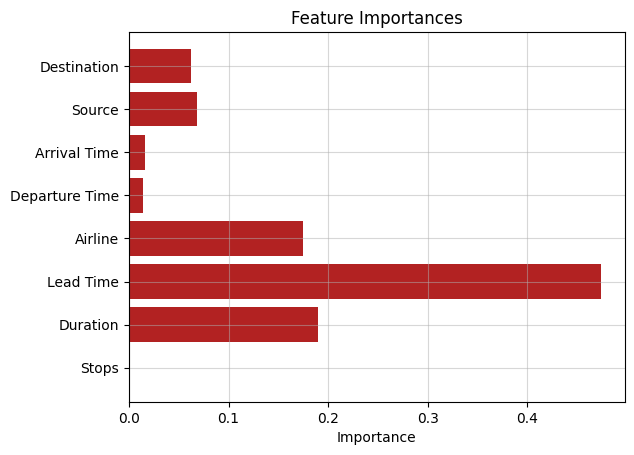

In [344]:
stop_sum = [0]
duration_sum = [0.1893]
lead_times_sum = [0.4740]
airline_sum = [0.0183 + 0.0635 + 0.0118 + 0.0364 + 0.0047 + 0.00007 + 0.0002 + 0.0402]
dep_time_sum = [0.0047 + 0.0058 + 0.0038]
arr_time_sum = [0.0053 + 0.0066 + 0.0042]
src_city_sum = [0.01034 + 0.0078 + 0.0097 + 0.0074 + 0.0219 + 0.0109]
dest_city_sum  = [0.0108 + 0.0068 + 0.0086 + 0.0103 + 0.0165 + 0.0089]

heights = [stop_sum[0], duration_sum[0], lead_times_sum[0], airline_sum[0], dep_time_sum[0], arr_time_sum[0], src_city_sum[0], dest_city_sum[0]]
labels = ['Stops', 'Duration', 'Lead Time', 'Airline', 'Departure Time', 'Arrival Time', 'Source', 'Destination']
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.barh(labels, heights, color='firebrick')
plt.grid(alpha=0.5)
plt.show()

Descriptive stats, unlog first